In [1]:
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)

# Práctica: Análisis y Reducción de Dimensionalidad con t-SNE

### Descripción:
Ahora haremos el mismo análisis y estructura de etapas que en las anteriores, pero utilizando t-SNE para la reducción de dimensionalidad y visualización de los datos. t-SNE es una técnica no lineal que se usa principalmente para la visualización, especialmente en espacios de alta dimensionalidad.

### Dataset:
El dataset `Wine` contiene 13 características químicas que describen el contenido de varios vinos, y está clasificado en 3 tipos de vinos diferentes. Las características incluyen:
- Alcohol
- Ácido málico
- Cenizas
- Alcalinidad de las cenizas
- Magnesio
- Fenoles totales
- Flavonoides
- Fenoles no flavonoides
- Proantocianinas
- Intensidad de color
- Tono
- OD280/OD315 de vinos diluidos
- Prolina




## Etapa 1: Exploración de los datos

### Objetivo:
Explorar el dataset que vamos a utilizar con **t-SNE**. Para mantener consistencia, utilizaremos el mismo dataset de vinos (Wine Dataset).

### Instrucciones:
1. Cargar el conjunto de datos `Wine` disponible en `sklearn`.
2. Mostrar las primeras filas del dataset y las características.
3. Visualizar la distribución de las clases para tener una idea general del problema de clasificación.

### Visualizaciones:
- **Distribución de las clases** en el conjunto de datos.


Aquí cargaremos el dataset de Wine y realizaremos un análisis exploratorio básico.

   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  
0                  

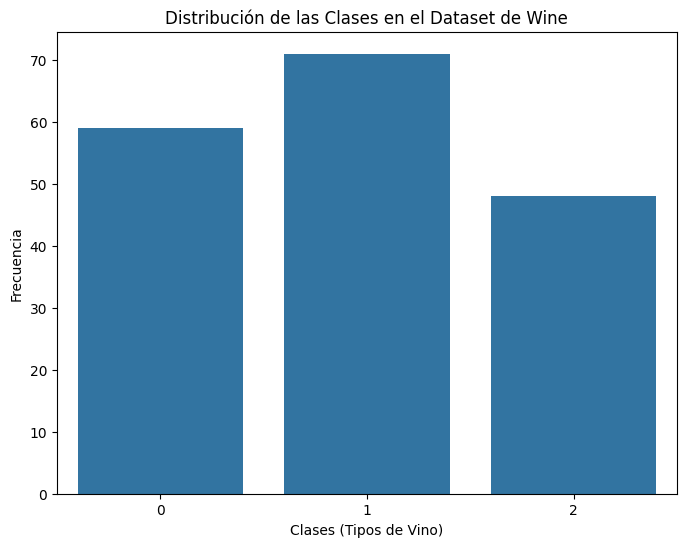

In [2]:
# Importar las bibliotecas necesarias
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine

# Cargar el dataset de Wine
wine_data = load_wine()
X_wine = pd.DataFrame(wine_data.data, columns=wine_data.feature_names)
y_wine = wine_data.target

# Mostrar las primeras filas del dataset
print(X_wine.head())

# Mostrar la distribución de las clases
plt.figure(figsize=(8, 6))
sns.countplot(x=y_wine)
plt.title("Distribución de las Clases en el Dataset de Wine")
plt.xlabel("Clases (Tipos de Vino)")
plt.ylabel("Frecuencia")
plt.show()



## Etapa 2: Aplicación de t-SNE

### Objetivo:
Aplicar **t-SNE** al conjunto de datos para reducir las dimensiones y visualizar las relaciones entre las clases en un espacio de menor dimensionalidad.

### Instrucciones:
1. Aplicar **t-SNE** para reducir las dimensiones del conjunto de datos a 2 y 3 dimensiones.
2. Visualizar las proyecciones en 2D y 3D.
3. Analizar la separación entre las clases.

### Visualizaciones:
- **Proyección en 2D con t-SNE**.
- **Proyección en 3D con t-SNE**.


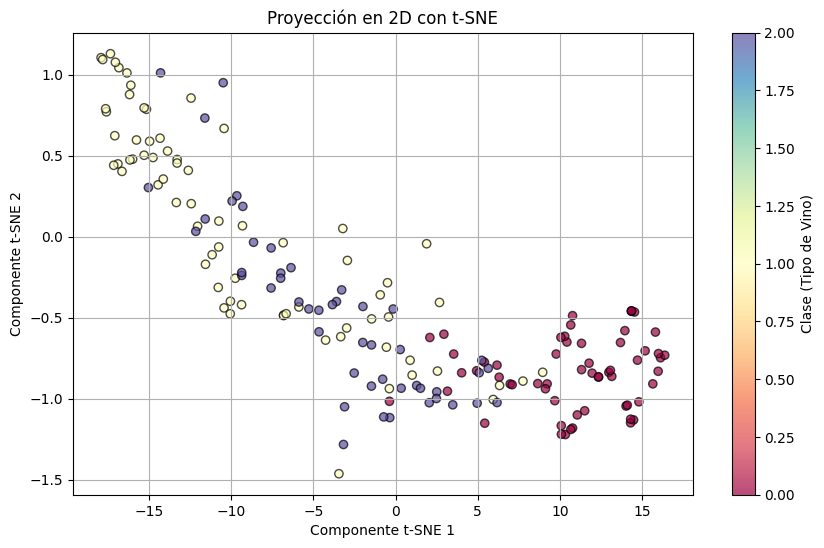

In [4]:
# Importar t-SNE
from sklearn.manifold import TSNE

# Aplicar t-SNE para reducir a 2 dimensiones
tsne_2d = TSNE(n_components=2, random_state=42)
X_tsne_2d = tsne_2d.fit_transform(X_wine)

# Visualización de la proyección en 2D con t-SNE
plt.figure(figsize=(10, 6))
plt.scatter(X_tsne_2d[:, 0], X_tsne_2d[:, 1], c=y_wine, cmap='Spectral', edgecolor='k', alpha=0.7)
plt.title('Proyección en 2D con t-SNE')
plt.xlabel('Componente t-SNE 1')
plt.ylabel('Componente t-SNE 2')
plt.colorbar(label='Clase (Tipo de Vino)')
plt.grid(True)
plt.show()


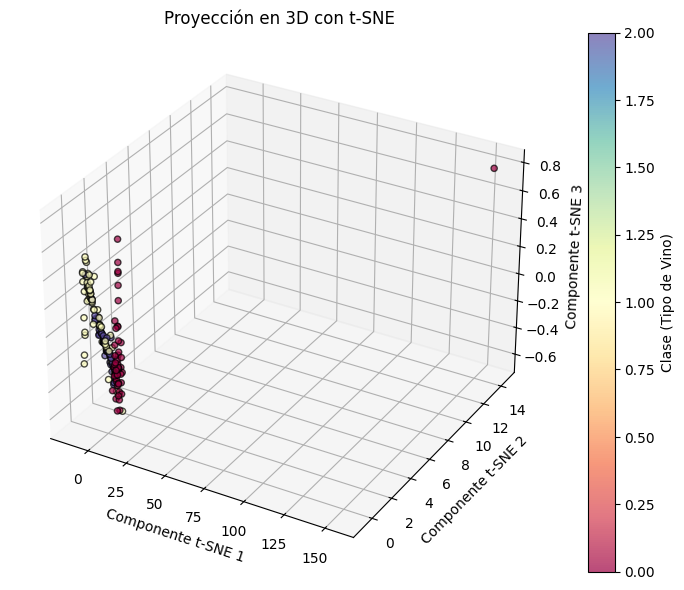

In [5]:
# Aplicar t-SNE para reducir a 3 dimensiones
tsne_3d = TSNE(n_components=3, random_state=42)
X_tsne_3d = tsne_3d.fit_transform(X_wine)

# Visualización de la proyección en 3D con t-SNE
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(X_tsne_3d[:, 0], X_tsne_3d[:, 1], X_tsne_3d[:, 2], c=y_wine, cmap='Spectral', edgecolor='k', alpha=0.7)

# Títulos y etiquetas
ax.set_title('Proyección en 3D con t-SNE')
ax.set_xlabel('Componente t-SNE 1')
ax.set_ylabel('Componente t-SNE 2')
ax.set_zlabel('Componente t-SNE 3')

# Mostrar la barra de colores para representar las clases
plt.colorbar(sc, label='Clase (Tipo de Vino)')
plt.show()

## Etapa 3: Entrenamiento de Modelos de Clasificación sin t-SNE

### Objetivo:
Entrenar modelos de clasificación utilizando todas las características originales del conjunto de datos sin aplicar LDA. Estos resultados servirán como referencia para comparar el rendimiento después de aplicar t-SNE.

### Instrucciones:
1. Entrenar los siguientes modelos de clasificación:
   - **Regresión Logística**
   - **Árbol de Decisión**
   - **Random Forest**
2. Evaluar el rendimiento de cada modelo utilizando:
   - **Accuracy**
   - **Precision**
   - **Recall**
   - **F1-score**
3. Mostrar la **matriz de confusión** y el **reporte de clasificación** para cada modelo.
4. Comparar los resultados obtenidos.

### Visualizaciones:
- **Matriz de Confusión**: Para analizar el rendimiento del modelo en cada clase.
- **Reporte de Clasificación**: Para observar precisión, recall y F1-score por clase.


--- Logistic Regression ---
Accuracy: 0.9815
Precision: 0.9823
Recall: 0.9815
F1 Score: 0.9814


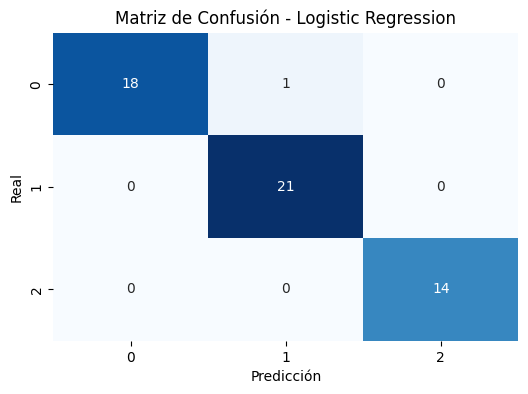

Reporte de Clasificación:
              precision    recall  f1-score   support

     class_0       1.00      0.95      0.97        19
     class_1       0.95      1.00      0.98        21
     class_2       1.00      1.00      1.00        14

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54



--- Decision Tree ---
Accuracy: 0.9630
Precision: 0.9638
Recall: 0.9630
F1 Score: 0.9628


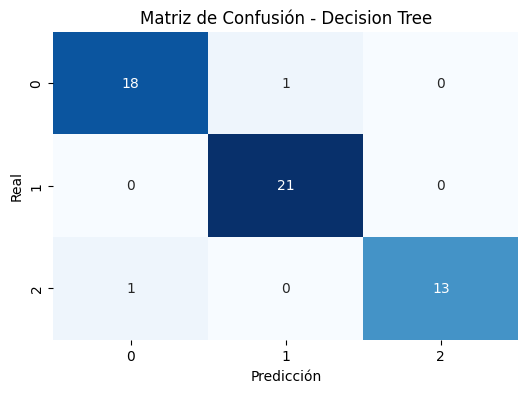

Reporte de Clasificación:
              precision    recall  f1-score   support

     class_0       0.95      0.95      0.95        19
     class_1       0.95      1.00      0.98        21
     class_2       1.00      0.93      0.96        14

    accuracy                           0.96        54
   macro avg       0.97      0.96      0.96        54
weighted avg       0.96      0.96      0.96        54



--- Random Forest ---
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000


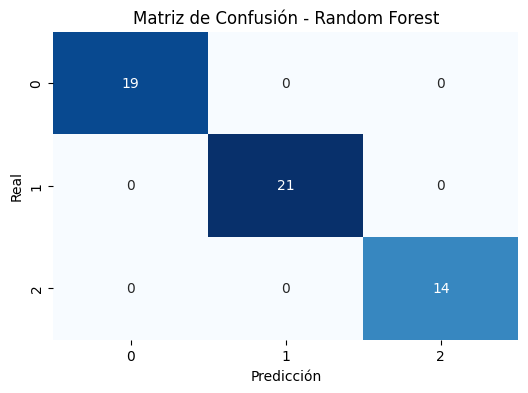

Reporte de Clasificación:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        19
     class_1       1.00      1.00      1.00        21
     class_2       1.00      1.00      1.00        14

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54





In [6]:
# Importar las bibliotecas necesarias
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
# Dividir los datos en entrenamiento y prueba (para uso posterior)
X_train, X_test, y_train, y_test = train_test_split(X_wine, y_wine, test_size=0.3, random_state=42)

# Definir los modelos
models = {
    'Logistic Regression': LogisticRegression(max_iter=200, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42)
}

# Entrenar y evaluar cada modelo
for name, model in models.items():
    print(f"--- {name} ---")
    
    # Entrenar el modelo
    model.fit(X_train, y_train)
    
    # Predicción
    y_pred = model.predict(X_test)
    
    # Mostrar métricas
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    
    # Matriz de confusión
    conf_matrix = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Matriz de Confusión - {name}')
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.show()
    
    # Reporte de clasificación
    print("Reporte de Clasificación:")
    print(classification_report(y_test, y_pred, target_names=wine_data.target_names))
    print("\n")


## Etapa 4: Entrenamiento de Modelos de Clasificación con t-SNE

### Objetivo:
Entrenar los modelos de clasificación utilizando las proyecciones de **t-SNE** y comparar el rendimiento con los modelos entrenados sin reducción de dimensionalidad.

### Instrucciones:
1. Aplicar t-SNE para reducir las dimensiones del conjunto de datos.
2. Entrenar los siguientes modelos de clasificación utilizando las proyecciones de t-SNE:
   - **Regresión Logística**
   - **Árbol de Decisión**
   - **Random Forest**
3. Evaluar el rendimiento de cada modelo utilizando:
   - **Accuracy**
   - **Precision**
   - **Recall**
   - **F1-score**
4. Mostrar la **matriz de confusión** y el **reporte de clasificación** para cada modelo.
5. Comparar los resultados con la **Etapa 3**.


--- Logistic Regression (con t-SNE) ---
Accuracy: 0.7407
Precision: 0.7290
Recall: 0.7407
F1 Score: 0.7338


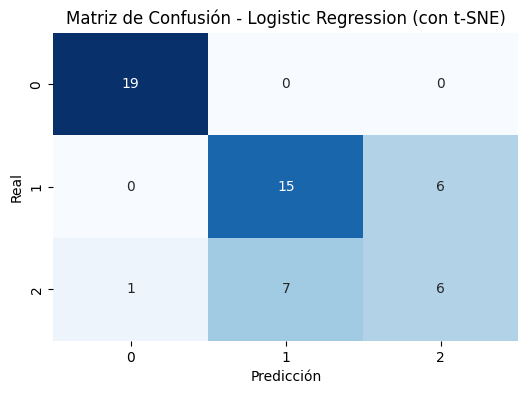

Reporte de Clasificación:
              precision    recall  f1-score   support

     class_0       0.95      1.00      0.97        19
     class_1       0.68      0.71      0.70        21
     class_2       0.50      0.43      0.46        14

    accuracy                           0.74        54
   macro avg       0.71      0.71      0.71        54
weighted avg       0.73      0.74      0.73        54



--- Decision Tree (con t-SNE) ---
Accuracy: 0.7593
Precision: 0.7593
Recall: 0.7593
F1 Score: 0.7589


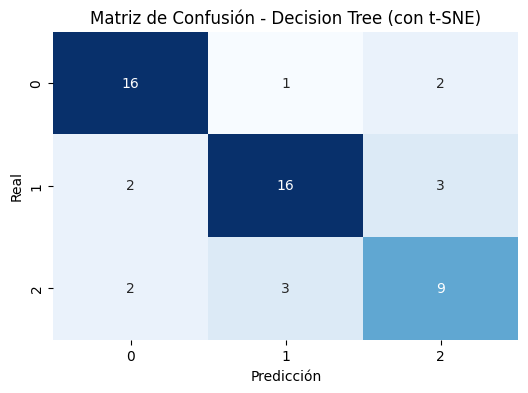

Reporte de Clasificación:
              precision    recall  f1-score   support

     class_0       0.80      0.84      0.82        19
     class_1       0.80      0.76      0.78        21
     class_2       0.64      0.64      0.64        14

    accuracy                           0.76        54
   macro avg       0.75      0.75      0.75        54
weighted avg       0.76      0.76      0.76        54



--- Random Forest (con t-SNE) ---
Accuracy: 0.7778
Precision: 0.8052
Recall: 0.7778
F1 Score: 0.7819


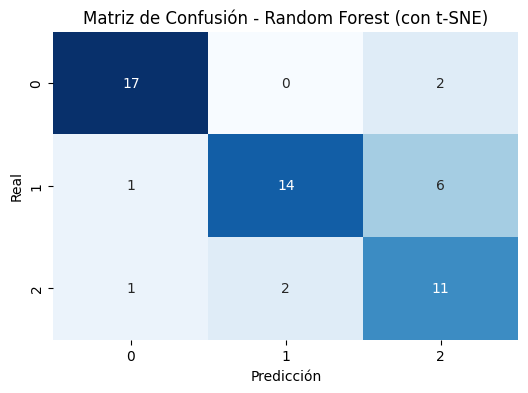

Reporte de Clasificación:
              precision    recall  f1-score   support

     class_0       0.89      0.89      0.89        19
     class_1       0.88      0.67      0.76        21
     class_2       0.58      0.79      0.67        14

    accuracy                           0.78        54
   macro avg       0.78      0.78      0.77        54
weighted avg       0.81      0.78      0.78        54





In [7]:
# Usar las proyecciones de t-SNE para entrenar modelos
X_train_tsne, X_test_tsne, y_train, y_test = train_test_split(X_tsne_2d, y_wine, test_size=0.3, random_state=42)

# Entrenar y evaluar cada modelo usando las proyecciones obtenidas por t-SNE
for name, model in models.items():
    print(f"--- {name} (con t-SNE) ---")
    
    # Entrenar el modelo
    model.fit(X_train_tsne, y_train)
    
    # Predicción
    y_pred_tsne = model.predict(X_test_tsne)
    
    # Mostrar métricas
    accuracy = accuracy_score(y_test, y_pred_tsne)
    precision = precision_score(y_test, y_pred_tsne, average='weighted')
    recall = recall_score(y_test, y_pred_tsne, average='weighted')
    f1 = f1_score(y_test, y_pred_tsne, average='weighted')
    
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    
    # Matriz de confusión
    conf_matrix_tsne = confusion_matrix(y_test, y_pred_tsne)
    plt.figure(figsize=(6, 4))
    sns.heatmap(conf_matrix_tsne, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Matriz de Confusión - {name} (con t-SNE)')
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.show()
    
    # Reporte de clasificación
    print("Reporte de Clasificación:")
    print(classification_report(y_test, y_pred_tsne, target_names=wine_data.target_names))
    print("\n")


## Etapa 5: Comparación de Resultados con y sin t-SNE

### Objetivo:
Comparar el rendimiento de los modelos de clasificación entrenados sin reducción de dimensionalidad (**Etapa 3**) con los modelos entrenados después de aplicar **t-SNE** (**Etapa 4**).

### Instrucciones:
1. Comparar las métricas de rendimiento (**accuracy**, **precision**, **recall**, **F1-score**) para los modelos entrenados con y sin t-SNE.
2. Visualizar la comparación en gráficos.
3. Analizar si la reducción de dimensionalidad mediante t-SNE ha mejorado o empeorado el rendimiento de los modelos.

### Visualizaciones:
- Gráficos de barras comparativos que muestren las métricas (accuracy, precision, recall, F1-score) para cada modelo con y sin t-SNE.


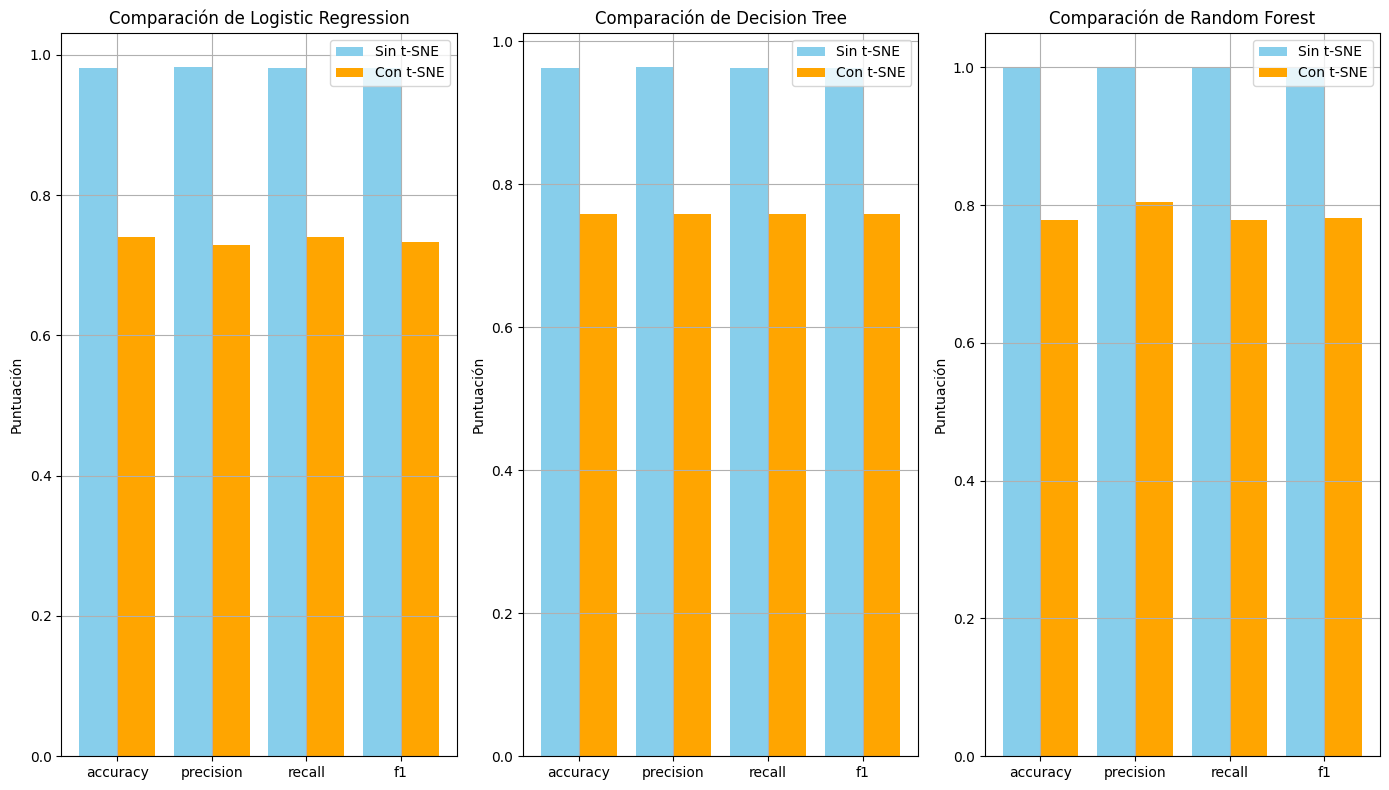

In [9]:
import numpy as np
# Definir las métricas obtenidas sin t-SNE y con t-SNE
results_tsne = {
    'Logistic Regression': {'no_tsne': {}, 'tsne': {}},
    'Decision Tree': {'no_tsne': {}, 'tsne': {}},
    'Random Forest': {'no_tsne': {}, 'tsne': {}}
}

# Entrenar y almacenar los resultados sin t-SNE (Etapa 3)
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    results_tsne[name]['no_tsne']['accuracy'] = accuracy_score(y_test, y_pred)
    results_tsne[name]['no_tsne']['precision'] = precision_score(y_test, y_pred, average='weighted')
    results_tsne[name]['no_tsne']['recall'] = recall_score(y_test, y_pred, average='weighted')
    results_tsne[name]['no_tsne']['f1'] = f1_score(y_test, y_pred, average='weighted')

# Entrenar y almacenar los resultados con t-SNE (Etapa 4)
for name, model in models.items():
    model.fit(X_train_tsne, y_train)
    y_pred_tsne = model.predict(X_test_tsne)
    
    results_tsne[name]['tsne']['accuracy'] = accuracy_score(y_test, y_pred_tsne)
    results_tsne[name]['tsne']['precision'] = precision_score(y_test, y_pred_tsne, average='weighted')
    results_tsne[name]['tsne']['recall'] = recall_score(y_test, y_pred_tsne, average='weighted')
    results_tsne[name]['tsne']['f1'] = f1_score(y_test, y_pred_tsne, average='weighted')

# Visualizar los resultados en gráficos comparativos
metrics = ['accuracy', 'precision', 'recall', 'f1']
x = np.arange(len(metrics))

plt.figure(figsize=(14, 8))

for i, model_name in enumerate(models.keys()):
    plt.subplot(1, 3, i+1)
    no_tsne_values = [results_tsne[model_name]['no_tsne'][metric] for metric in metrics]
    tsne_values = [results_tsne[model_name]['tsne'][metric] for metric in metrics]
    
    plt.bar(x - 0.2, no_tsne_values, width=0.4, label='Sin t-SNE', color='skyblue')
    plt.bar(x + 0.2, tsne_values, width=0.4, label='Con t-SNE', color='orange')
    
    plt.xticks(x, metrics)
    plt.title(f'Comparación de {model_name}')
    plt.ylabel('Puntuación')
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()


Ventajas de t-SNE: t-SNE es excelente para la visualización de datos complejos en espacios de alta dimensión, ya que preserva las relaciones de proximidad locales. Esto puede ser útil para identificar patrones, clústeres, y anomalías en los datos.

Limitaciones: t-SNE no es necesariamente la mejor opción para la reducción de dimensionalidad cuando el objetivo es mejorar el rendimiento de un modelo de clasificación, ya que está diseñado principalmente para visualización. Además, su capacidad de reproducir los mismos resultados puede ser un desafío debido a su naturaleza estocástica.